# ML-06: Signal Audit: Do the Flags Hold?

This audit keeps Lane 2: ranking visible pages for refresh review. It uses the same March-to-April example as my data contract and completed baseline.

One row is one eligible pseudonymized client-content item. March 2–31, 2026 supplies the signals; April 1–30 supplies the decline proxy. A positive label means April impressions are more than 20% below March impressions. It does not show that editing the page would help.

## 1. Distributions

I check impression volume, prior-window momentum, and search position. Volume and momentum are the two inputs to my completed rule. Position is an additional signal to audit, with a separate CTR-by-position check linked to FlyRank's CTR-fix logic.

I require GSC availability on all 30 March days, at least 100 March impressions, and positive impressions in the first 15 days so momentum is defined. Only rows with all 30 April days enter the decline tests. These are the baseline's eligibility rules; April coverage does not decide who enters its queue.

In [ ]:
from pathlib import Path
import json
import os
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "skills/README.md").exists())
OUTPUTS = ROOT / "work/outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)
REL = "hf://datasets/FlyRank/internship-warehouse"
KEYS = ["client_hash_id", "content_hash_id"]
LABEL = "is_declining_label"
FEATURES = ["impressions_feature_30d", "momentum_pct", "weighted_position_feature_30d"]
con = duckdb.connect()
con.execute("SET enable_progress_bar = false")
if os.environ.get("SSL_CERT_FILE"):
    con.execute("LOAD httpfs")
    con.execute("SET ca_cert_file = ?", [os.environ["SSL_CERT_FILE"]])

def monthly_pages(month, start, end):
    # Aggregate each monthly partition once; cached page aggregates stay out of git.
    cache = OUTPUTS / f"w04_audit_{month}_v1.parquet"
    if cache.exists():
        print(f"Loading cached aggregates: {month}")
        return pd.read_parquet(cache)
    print(f"Aggregating warehouse partition: {month}")
    from huggingface_hub import get_token
    token = get_token()
    if not token:
        raise RuntimeError("A stored Hugging Face READ token or HF_TOKEN is required.")
    con.execute("CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN ?)", [token])
    del token
    source = f"{REL}/fact_content_daily_performance/month={month}/*.parquet"
    frame = con.sql(f"""
        SELECT client_hash_id, content_hash_id,
            COUNT(*) AS source_rows,
            COUNT(*) - COUNT(DISTINCT report_date) AS duplicate_rows,
            MIN(report_date) AS source_first_date,
            MAX(report_date) AS source_last_date,
            COUNT(DISTINCT report_date) FILTER (WHERE available) AS gsc_days,
            COUNT(*) FILTER (WHERE available AND
                (gsc_impressions IS NULL OR gsc_clicks IS NULL
                 OR gsc_sum_position IS NULL)) AS missing_gsc_rows,
            SUM(gsc_impressions) FILTER (WHERE available) AS impressions,
            SUM(gsc_clicks) FILTER (WHERE available) AS clicks,
            SUM(gsc_sum_position) FILTER (WHERE available) AS position_sum,
            SUM(gsc_impressions) FILTER (
                WHERE available AND report_date <= DATE '{start}' + INTERVAL 14 DAY
            ) AS early15,
            SUM(gsc_impressions) FILTER (
                WHERE available AND report_date > DATE '{start}' + INTERVAL 14 DAY
            ) AS late15
        FROM (
            SELECT *, gsc_data_available IS TRUE
                AND report_date BETWEEN DATE '{start}' AND DATE '{end}' AS available
            FROM read_parquet('{source}')
        )
        GROUP BY client_hash_id, content_hash_id
    """).df()
    assert frame["duplicate_rows"].sum() == 0, "Duplicate daily keys: investigate before caching."
    frame.to_parquet(cache, index=False)
    return frame

march = monthly_pages("2026-03", "2026-03-02", "2026-03-31")
april = monthly_pages("2026-04", "2026-04-01", "2026-04-30")
source_checks = pd.DataFrame([
    {"partition": month, "n_source_rows": int(frame["source_rows"].sum()),
     "first_date": str(frame["source_first_date"].min().date()),
     "last_date": str(frame["source_last_date"].max().date()),
     "extra_duplicate_rows": int(frame["duplicate_rows"].sum()),
     "missing_gsc_rows_in_window": int(frame["missing_gsc_rows"].sum())}
    for month, frame in [("2026-03", march), ("2026-04", april)]
])
display(source_checks)
assert source_checks["extra_duplicate_rows"].eq(0).all()
assert source_checks["missing_gsc_rows_in_window"].eq(0).all()
assert source_checks["first_date"].tolist() == ["2026-03-01", "2026-04-01"]
assert source_checks["last_date"].tolist() == ["2026-03-31", "2026-04-30"]
# The March count was recorded in ML-04. Only these two partitions are read.
assert source_checks.loc[0, "n_source_rows"] == 9_841_378

eligible = march["gsc_days"].eq(30) & march["impressions"].ge(100)
undefined_momentum_n = int((eligible & ~march["early15"].gt(0)).sum())
feature_frame = march.loc[eligible & march["early15"].gt(0),
                          KEYS + ["impressions", "clicks", "position_sum", "early15", "late15"]].copy()
feature_frame = feature_frame.rename(columns={"impressions": "impressions_feature_30d"})
feature_frame["momentum_pct"] = 100 * (feature_frame["late15"] - feature_frame["early15"]) / feature_frame["early15"]
feature_frame["ctr_feature_30d_pct"] = 100 * feature_frame["clicks"] / feature_frame["impressions_feature_30d"]
feature_frame["weighted_position_feature_30d"] = (
    feature_frame["position_sum"] / feature_frame["impressions_feature_30d"]
).where(feature_frame["position_sum"].gt(0))
targets = april.loc[april["gsc_days"].eq(30), KEYS + ["impressions"]].rename(
    columns={"impressions": "target_impressions"})
evaluation_frame = feature_frame.merge(targets, on=KEYS, validate="one_to_one")
evaluation_frame[LABEL] = (
    evaluation_frame["target_impressions"] < 0.80 * evaluation_frame["impressions_feature_30d"]
).astype(int)
base_rate = evaluation_frame[LABEL].mean()
print(f"March feature rows: {len(feature_frame):,}")
print(f"Excluded for undefined momentum: {undefined_momentum_n:,}")
print(f"Evaluation rows: {len(evaluation_frame):,}")
print(f"March rows without complete April coverage: {len(feature_frame) - len(evaluation_frame):,}")
print(f"April decline-proxy base rate: {base_rate:.1%}")

Loading cached aggregates: 2026-03
Loading cached aggregates: 2026-04


,partition,n_source_rows,first_date,last_date,extra_duplicate_rows,missing_gsc_rows_in_window
0,2026-03,9841378,2026-03-01,2026-03-31,0,0
1,2026-04,10424730,2026-04-01,2026-04-30,0,0


March feature rows: 62,397
Excluded for undefined momentum: 0
Evaluation rows: 50,641
March rows without complete April coverage: 11,756
April decline-proxy base rate: 47.3%


,count,mean,std,min,50%,90%,99%,max,missing_n
impressions_feature_30d,62397.0,3618.43,7578.49,100.00,1295.00,8444.60,35103.08,239235.00,0
momentum_pct,62397.0,15.38,95.59,-99.89,-2.20,82.02,327.17,6100.00,0
weighted_position_feature_30d,62397.0,13.15,12.95,0.02,7.79,30.81,63.81,90.74,0
ctr_feature_30d_pct,62397.0,0.25,0.35,0.00,0.15,0.61,1.57,11.50,0


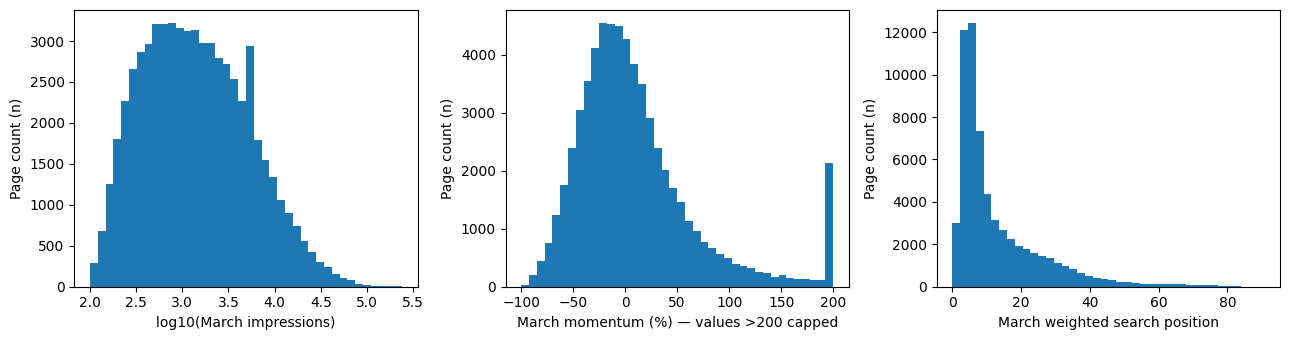

Momentum values above the plotting cap: 2045
Weighted positions below 1: 262


In [2]:
distribution_fields = FEATURES + ["ctr_feature_30d_pct"]
distribution_table = feature_frame[distribution_fields].describe(
    percentiles=[0.5, 0.9, 0.99]).T
distribution_table["missing_n"] = feature_frame[distribution_fields].isna().sum()
display(distribution_table.round(2))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].hist(np.log10(feature_frame["impressions_feature_30d"]), bins=40)
axes[0].set_xlabel("log10(March impressions)")
axes[1].hist(feature_frame["momentum_pct"].clip(upper=200), bins=40)
axes[1].set_xlabel("March momentum (%) — values >200 capped")
axes[2].hist(feature_frame["weighted_position_feature_30d"].dropna(), bins=40)
axes[2].set_xlabel("March weighted search position")
for ax in axes:
    ax.set_ylabel("Page count (n)")
fig.tight_layout()
plt.show()
print("Momentum values above the plotting cap:", int(feature_frame["momentum_pct"].gt(200).sum()))
print("Weighted positions below 1:", int(feature_frame["weighted_position_feature_30d"].lt(1).sum()))

March impressions have a heavy right tail: the median is 1,295, the 99th percentile is 35,103, and the maximum is 239,235. Momentum ranges from -99.9% to 6,100%; a small first-half denominator can produce a large gain. The chart caps 2,045 values above 200% for readability; all tables use the original values.

There are 62,397 March-eligible pages and 50,641 with an observable April outcome. The remaining 11,756 pages do not enter the decline tests. No audited fields are missing after eligibility filtering, but 262 weighted positions are below 1; this limits literal rank interpretation.

## 2. Signal test #1 / #2 / #3 (verdict each)

Each table shows the page count, number matching the April proxy, and decline rate. Buckets are descriptive checks on this one cutoff, not held-out model results. I keep the volume and momentum boundaries from the completed baseline; position tiers are above 0 to 3, above 3–10, above 10–20, and above 20.

### Signal 1: feature-window volume

**Question.** Does higher March impression volume track more April decline?

In [3]:
def bucket_table(column, bins, labels):
    values = evaluation_frame[column]
    buckets = pd.cut(values, bins=bins, labels=labels, include_lowest=True)
    table = (evaluation_frame.assign(bucket=buckets)
             .groupby("bucket", observed=False)[LABEL]
             .agg(n="size", declining_n="sum", rate="mean").reset_index())
    table["decline_rate_pct"] = 100 * table.pop("rate")
    assert int(table["n"].sum()) == int(values.notna().sum())
    print(f"Missing or invalid signal rows excluded: {values.isna().sum():,}")
    print(f"Overall base rate: {base_rate:.1%}")
    display(table.round(1))
    return table

volume_table = bucket_table("impressions_feature_30d",
    [99, 499, 2_999, 29_999, np.inf],
    ["100–499", "500–2,999", "3,000–29,999", "30,000+"])

Missing or invalid signal rows excluded: 0
Overall base rate: 47.3%


,bucket,n,declining_n,decline_rate_pct
0,100–499,7413,2464,33.2
1,"500–2,999",24934,13054,52.4
2,"3,000–29,999",17455,8121,46.5
3,"30,000+",839,337,40.2


**Verdict: MIXED**

Decline rates across ascending volume buckets are 33.2%, 52.4%, 46.5%, and 40.2%. They do not rise steadily with volume. The baseline's 500-impression gate is a practical visibility threshold; these results do not establish that it is optimal or that the most visible pages are the most likely to decline.

### Signal 2: prior-window momentum

**Question.** Does a larger loss from March 2–16 to March 17–31 track more April decline? Both 15-day windows finish before the outcome window.

In [4]:
momentum_table = bucket_table("momentum_pct",
    [-np.inf, -50, -20, 0, 20, np.inf],
    ["<= -50%", "(-50%, -20%]", "(-20%, 0%]", "(0%, 20%]", "> 20%"])

Missing or invalid signal rows excluded: 0
Overall base rate: 47.3%


,bucket,n,declining_n,decline_rate_pct
0,<= -50%,4171,3375,80.9
1,"(-50%, -20%]",11439,6948,60.7
2,"(-20%, 0%]",9976,4921,49.3
3,"(0%, 20%]",8398,3428,40.8
4,> 20%,16657,5304,31.8


**Verdict: CONFIRMED**

Decline rates fall steadily from 80.9% to 60.7%, 49.3%, 40.8%, and 31.8% as March momentum improves. This supports using recent momentum loss to prioritize review in this example. It is an observed association at one cutoff, not evidence that refreshing a page causes recovery.

This momentum uses two March windows. It is different from a future change field that directly defines the April label.

### Signal 3: feature-window search position

**Question.** Does worse March search position track more April decline? Position is impression-weighted, using `SUM(gsc_sum_position) / SUM(gsc_impressions)`. Nonpositive values are treated as unavailable. The contract formula produces some values below 1, so the first tier is above 0 to 3. I retain that formula and treat this as a directional position check; exact rank interpretation needs a source-definition check.

In [5]:
position_bins = [0, 3, 10, 20, np.inf]
position_labels = ["above 0 to 3", "above 3–10", "above 10–20", "above 20"]
position_table = bucket_table("weighted_position_feature_30d", position_bins, position_labels)

Missing or invalid signal rows excluded: 0
Overall base rate: 47.3%


,bucket,n,declining_n,decline_rate_pct
0,above 0 to 3,4996,2786,55.8
1,above 3–10,25666,11623,45.3
2,above 10–20,9418,4497,47.7
3,above 20,10561,5070,48.0


**Verdict: MIXED**

Decline rates are 55.8%, 45.3%, 47.7%, and 48.0% across worsening position tiers. The best-position tier has the highest rate, followed by a modest rise across the other tiers. This does not support a simple rule that worse position means more future decline. I keep position out of the completed baseline.

## 3. The flag-linked test

**Question.** Is March CTR lower at worse search positions? FlyRank's CTR-fix logic compares CTR with position context; the lane guide also recommends comparing pages within position tiers. This checks the underlying association, not whether a product flag was correctly assigned.

I use all March-eligible pages for this check, including those without an April label. CTR is `100 × clicks / impressions`, so 0.76 means 0.76%. The table includes median page CTR and pooled CTR; pooled CTR weights pages by impressions. Volume is also a flag-linked signal behind quick-win, but its decline test above does not establish an opportunity or an editing benefit.

In [6]:
ctr_context = feature_frame.assign(position_bucket=pd.cut(
    feature_frame["weighted_position_feature_30d"],
    bins=position_bins, labels=position_labels, include_lowest=True))
ctr_position_table = (ctr_context.groupby("position_bucket", observed=False)
    .agg(n=("ctr_feature_30d_pct", "size"),
         median_page_ctr_pct=("ctr_feature_30d_pct", "median"),
         impressions_n=("impressions_feature_30d", "sum"),
         clicks_n=("clicks", "sum")).reset_index())
ctr_position_table["pooled_ctr_pct"] = (
    100 * ctr_position_table["clicks_n"] / ctr_position_table["impressions_n"].replace(0, np.nan))
assert ctr_position_table["n"].sum() == feature_frame["weighted_position_feature_30d"].notna().sum()
display(ctr_position_table.round(2))
print("March pages excluded for unavailable position:",
      int(feature_frame["weighted_position_feature_30d"].isna().sum()))

,position_bucket,n,median_page_ctr_pct,impressions_n,clicks_n,pooled_ctr_pct
0,above 0 to 3,6091,0.21,29037789.0,105926.0,0.36
1,above 3–10,30820,0.20,121208801.0,378318.0,0.31
2,above 10–20,12033,0.13,24910216.0,80218.0,0.32
3,above 20,13453,0.02,50622146.0,68262.0,0.13


March pages excluded for unavailable position: 0


**Verdict: MIXED**

Median page CTR falls across the four tiers: 0.213%, 0.196%, 0.127%, and 0.023%. Pooled CTR is 0.365%, 0.312%, 0.322%, and 0.135%, with a small reversal between the middle tiers. The broad association supports checking position context, but the pattern depends on how pages are weighted.

This does not validate a specific CTR-fix threshold or show that changing a title would improve clicks. Query intent, client mix, and search-result layout may explain differences; the position-definition caveat also applies. I do not use product flags as features or labels.

## 4. What this means in practice

I would keep the existing rule: review pages with at least 500 March impressions and momentum at or below -20%, ranked by the size of that loss. Momentum has the clearest observed relationship with April decline; volume remains a visibility gate, while position and CTR need context before suggesting an action. These are exploratory results from one cutoff, with pages from the same client potentially sharing shocks; Week 5 still needs honest validation, and none of these checks establishes refresh benefit.

The completed `w04_baseline_score.ipynb` contains the score, reason code, action label, queue export, and top-20 review. This notebook adds the full signal audit and writes an aggregate metrics receipt.

In [7]:
# Record aggregate receipts only. The completed baseline owns the queue CSV.
verdicts = {"volume": "MIXED", "momentum": "CONFIRMED", "position": "MIXED", "ctr_by_position": "MIXED"}
assert pd.Timestamp("2026-03-31") < pd.Timestamp("2026-04-01")
assert not set(FEATURES) & {LABEL, "target_impressions", "trend_pct", "trend_direction"}
assert LABEL not in feature_frame.columns and "target_impressions" not in feature_frame.columns
assert not feature_frame.duplicated(KEYS).any()
assert not evaluation_frame.duplicated(KEYS).any()
assert np.isfinite(feature_frame[["impressions_feature_30d", "momentum_pct"]]).all().all()

def records(table):
    return json.loads(table.to_json(orient="records"))

receipt = {
    "lane": 2,
    "feature_window": ["2026-03-02", "2026-03-31"],
    "outcome_window": ["2026-04-01", "2026-04-30"],
    "decline_ratio_strictly_below": 0.80,
    "feature_rows": len(feature_frame),
    "evaluation_rows": len(evaluation_frame),
    "undefined_momentum_rows_excluded": undefined_momentum_n,
    "base_rate": float(base_rate),
    "source_checks": records(source_checks),
    "distributions": records(distribution_table.reset_index(names="signal")),
    "verdicts": verdicts,
    "volume_buckets": records(volume_table),
    "momentum_buckets": records(momentum_table),
    "position_buckets": records(position_table),
    "ctr_by_position": records(ctr_position_table),
    "limitations": ["One exploratory cutoff; no held-out evaluation",
                    "Pages within a client may share shocks",
                    "Decline proxy does not measure refresh benefit",
                    "Complete-window eligibility limits generalization"],
}
receipt_path = OUTPUTS / "w04_signal_audit_metrics.json"
receipt_path.write_text(json.dumps(receipt, indent=2, allow_nan=False) + "\n", encoding="utf-8")
print("Wrote: work/outputs/w04_signal_audit_metrics.json")
print("All signal-audit checks passed.")

Wrote: work/outputs/w04_signal_audit_metrics.json
All signal-audit checks passed.


## Self-check

- [x] Every section contains markdown reasoning and the code that backs it.
- [x] The notebook runs top to bottom with no errors.
- [x] Three signal verdicts and the flag-linked test have visible bucket counts.
- [x] Only March measurements enter the signals; April is used for the decline tests.
- [x] Displayed outputs contain aggregates, with no client names, page URLs, or private queries.
- [x] Claims describe observed associations and decision-support, not refresh benefit.
- [x] Committed under `work/notebooks/`, then submitted the repo URL on the card.